# 01 - Model Inference on IEMOCAP

Goal: load IEMOCAP audio samples and run the pretrained SpeechBrain wav2vec2-IEMOCAP emotion classifier.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from speech_xai_project import audio, config, masking, model, plotting

project_config = config.load_config(PROJECT_ROOT / 'configs' / 'default.yaml')
IEMOCAP_ROOT = config.project_path(project_config['paths']['iemocap_root'])
METADATA_CSV = config.project_path(project_config['paths']['metadata_csv'])
PREDICTIONS_CSV = config.project_path(project_config['paths']['predictions_csv'])
EVALUATION_SUMMARY_CSV = config.project_path('results/classifier_evaluation_summary.csv')
MODEL_SOURCE = project_config['model']['speechbrain_source']
MODEL_SAVEDIR = config.project_path(project_config['model']['savedir'])
TARGET_SAMPLE_RATE = project_config['model']['sample_rate']
EVALUATION_EXAMPLES_PER_CLASS = 5
IEMOCAP_TO_MODEL_LABEL = {'exc': 'hap'}

PREDICTIONS_CSV.parent.mkdir(parents=True, exist_ok=True)

In [2]:
metadata_table = audio.load_metadata_or_discover(METADATA_CSV, IEMOCAP_ROOT)
if metadata_table.empty:
    raise FileNotFoundError(
        f'No audio files found. Add IEMOCAP audio under {IEMOCAP_ROOT} '
        f'or create {METADATA_CSV} with audio_id,audio_path,true_label.'
    )

metadata_table.head()

,audio_id,audio_path,true_label,session,dialog_id,start,end,valence,activation,dominance
0,Ses01F_impro01_F000,C:\Users\mateu\repos\gradient_based_speach_xai...,neu,Session1,Ses01F_impro01,6.2901,8.2357,2.5,2.5,2.5
1,Ses01F_impro01_F001,C:\Users\mateu\repos\gradient_based_speach_xai...,neu,Session1,Ses01F_impro01,10.0100,11.3925,2.5,2.5,2.5
2,Ses01F_impro01_F002,C:\Users\mateu\repos\gradient_based_speach_xai...,neu,Session1,Ses01F_impro01,14.8872,18.0175,2.5,2.5,2.5
3,Ses01F_impro01_F005,C:\Users\mateu\repos\gradient_based_speach_xai...,neu,Session1,Ses01F_impro01,27.4600,31.4900,2.5,3.5,2.0
4,Ses01F_impro01_F012,C:\Users\mateu\repos\gradient_based_speach_xai...,ang,Session1,Ses01F_impro01,85.2700,88.0200,2.0,3.5,3.5


audio_id: Ses01F_impro01_F000
duration: 1.9455625


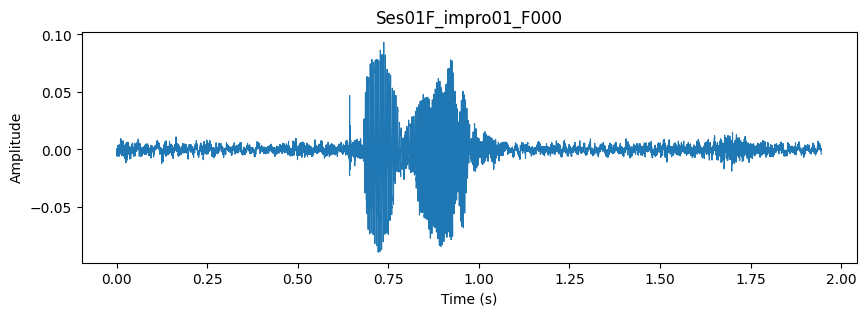

In [3]:
sample_row = metadata_table.iloc[0]
sample_waveform, sample_rate = audio.load_waveform(sample_row.audio_path, TARGET_SAMPLE_RATE)
print('audio_id:', sample_row.audio_id)
print('duration:', audio.duration_seconds(sample_waveform, sample_rate))
plotting.plot_waveform(sample_waveform, sample_rate, title=str(sample_row.audio_id));

In [4]:
metadata_table = metadata_table.copy()
metadata_table['model_true_label'] = metadata_table['true_label'].replace(IEMOCAP_TO_MODEL_LABEL)
known_model_labels = ['ang', 'hap', 'neu', 'sad']
evaluation_table = (
    metadata_table[metadata_table['model_true_label'].isin(known_model_labels)]
    .groupby('model_true_label', group_keys=False)
    .head(EVALUATION_EXAMPLES_PER_CLASS)
    .reset_index(drop=True)
)

print('Evaluation subset size:', len(evaluation_table))
print(evaluation_table['model_true_label'].value_counts().sort_index())

classifier = model.load_speechbrain_classifier(MODEL_SOURCE, MODEL_SAVEDIR)
prediction_rows = []

for row in evaluation_table.itertuples(index=False):
    waveform, sample_rate = audio.load_waveform(row.audio_path, TARGET_SAMPLE_RATE)
    prediction = model.classify_waveform(classifier, audio.waveform_to_batch(waveform))
    prediction_rows.append({
        'audio_id': row.audio_id,
        'audio_path': row.audio_path,
        'true_label': getattr(row, 'true_label', None),
        'model_true_label': row.model_true_label,
        'duration_seconds': audio.duration_seconds(waveform, sample_rate),
        'predicted_label': prediction.predicted_label,
        'predicted_index': prediction.predicted_index,
        'predicted_confidence': prediction.predicted_confidence,
    })

predictions_table = pd.DataFrame(prediction_rows)
predictions_table

Evaluation subset size: 20
model_true_label
ang    5
hap    5
neu    5
sad    5
Name: count, dtype: int64


C:\Users\mateu\repos\gradient_based_speach_xai\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.12_3.12.2800.0_x64__qbz5n2kfra8p0\Lib\inspect.py:1007: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  if ismodule(module) and hasattr(module, '__file__'):


C:\Users\mateu\repos\gradient_based_speach_xai\.venv\Lib\site-packages\transformers\configuration_utils.py:335: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


speechbrain.lobes.models.huggingface_transformers.huggingface - Wav2Vec2Model is frozen.


CategoricalEncoder.expect_len was never called: assuming category count of 4 to be correct! Sanity check your encoder using `.expect_len`. Ensure that downstream code also uses the correct size. If you are sure this does not apply to you, use `.ignore_len`.


,audio_id,audio_path,true_label,model_true_label,duration_seconds,predicted_label,predicted_index,predicted_confidence
0,Ses01F_impro01_F000,C:\Users\mateu\repos\gradient_based_speach_xai...,neu,neu,1.945563,neu,0,1.000000
1,Ses01F_impro01_F001,C:\Users\mateu\repos\gradient_based_speach_xai...,neu,neu,1.382437,neu,0,1.000000
2,Ses01F_impro01_F002,C:\Users\mateu\repos\gradient_based_speach_xai...,neu,neu,3.130250,neu,0,1.000000
3,Ses01F_impro01_F005,C:\Users\mateu\repos\gradient_based_speach_xai...,neu,neu,4.029937,neu,0,1.000000
4,Ses01F_impro01_F012,C:\Users\mateu\repos\gradient_based_speach_xai...,ang,ang,2.750000,ang,1,1.000000
5,Ses01F_impro01_F014,C:\Users\mateu\repos\gradient_based_speach_xai...,neu,neu,5.070000,neu,0,0.999965
6,Ses01F_impro01_M011,C:\Users\mateu\repos\gradient_based_speach_xai...,ang,ang,7.239937,ang,1,1.000000
7,Ses01F_impro01_M013,C:\Users\mateu\repos\gradient_based_speach_xai...,ang,ang,6.029937,ang,1,1.000000
8,Ses01F_impro02_F000,C:\Users\mateu\repos\gradient_based_speach_xai...,sad,sad,9.331188,sad,3,1.000000
9,Ses01F_impro02_F001,C:\Users\mateu\repos\gradient_based_speach_xai...,sad,sad,2.930000,neu,0,0.838504


In [5]:
predictions_table['is_correct'] = predictions_table['model_true_label'] == predictions_table['predicted_label']
predictions_table.to_csv(PREDICTIONS_CSV, index=False)
accuracy = predictions_table['is_correct'].mean()
mean_confidence = predictions_table['predicted_confidence'].mean()

per_class_accuracy = (
    predictions_table.groupby('model_true_label', as_index=False)
    .agg(
        examples=('audio_id', 'count'),
        accuracy=('is_correct', 'mean'),
        mean_confidence=('predicted_confidence', 'mean'),
    )
)

confusion_matrix = pd.crosstab(
    predictions_table['model_true_label'],
    predictions_table['predicted_label'],
    rownames=['true'],
    colnames=['predicted'],
    dropna=False,
)

evaluation_summary = pd.DataFrame([
    {
        'examples': len(predictions_table),
        'examples_per_class': EVALUATION_EXAMPLES_PER_CLASS,
        'accuracy': accuracy,
        'mean_confidence': mean_confidence,
    }
])
evaluation_summary.to_csv(EVALUATION_SUMMARY_CSV, index=False)

print('Overall accuracy:', round(accuracy, 3))
print('Mean predicted confidence:', round(mean_confidence, 3))
display(per_class_accuracy)
display(confusion_matrix)
evaluation_summary

Overall accuracy: 0.9
Mean predicted confidence: 0.992


,model_true_label,examples,accuracy,mean_confidence
0,ang,5,0.8,1.000000
1,hap,5,1.0,1.000000
2,neu,5,1.0,0.999993
3,sad,5,0.8,0.967701


predicted,ang,hap,neu,sad
true,,,,
ang,4,0,1,0
hap,0,5,0,0
neu,0,0,5,0
sad,0,0,1,4


,examples,examples_per_class,accuracy,mean_confidence
0,20,5,0.9,0.991923


## Waveform With Occlusion Attribution

This is a quick sanity-check attribution for Notebook 01. It is not SpeechXAI or LeGrad: each short time window is silenced, the model is run again, and the attribution score is the confidence drop for the original predicted class.

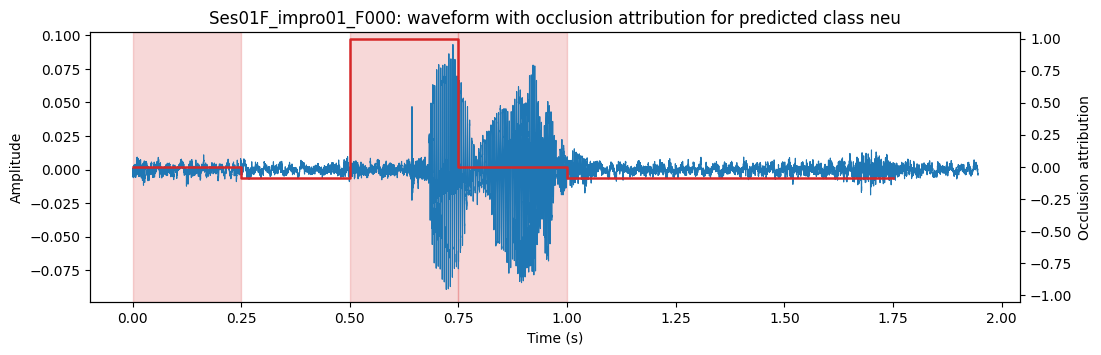

,audio_id,start,end,score,normalized_score
0,Ses01F_impro01_F000,0.00,0.250000,0.000000e+00,0.000000
1,Ses01F_impro01_F000,0.25,0.500000,-1.192093e-07,-0.083333
2,Ses01F_impro01_F000,0.50,0.750000,1.430511e-06,1.000000
3,Ses01F_impro01_F000,0.75,1.000000,0.000000e+00,0.000000
4,Ses01F_impro01_F000,1.00,1.250000,-1.192093e-07,-0.083333
5,Ses01F_impro01_F000,1.25,1.500000,-1.192093e-07,-0.083333
6,Ses01F_impro01_F000,1.50,1.750000,-1.192093e-07,-0.083333
7,Ses01F_impro01_F000,1.75,1.945563,-1.192093e-07,-0.083333


In [6]:
attribution_row = predictions_table.iloc[0]
attribution_waveform, attribution_sample_rate = audio.load_waveform(
    attribution_row.audio_path,
    TARGET_SAMPLE_RATE,
)
attribution_duration = audio.duration_seconds(attribution_waveform, attribution_sample_rate)
original_prediction = model.classify_waveform(classifier, audio.waveform_to_batch(attribution_waveform))
target_index = original_prediction.predicted_index
target_label = original_prediction.predicted_label
original_target_confidence = float(original_prediction.probabilities[target_index])

window_seconds = 0.25
window_starts = np.arange(0.0, attribution_duration, window_seconds)
attribution_rows = []

for window_start in window_starts:
    window_end = min(float(window_start + window_seconds), attribution_duration)
    window_table = pd.DataFrame(
        [{'audio_id': attribution_row.audio_id, 'start': window_start, 'end': window_end, 'score': 1.0}]
    )
    masked_waveform = masking.silence_intervals(
        attribution_waveform,
        attribution_sample_rate,
        window_table,
    )
    masked_prediction = model.classify_waveform(classifier, audio.waveform_to_batch(masked_waveform))
    masked_target_confidence = float(masked_prediction.probabilities[target_index])
    attribution_rows.append(
        {
            'audio_id': attribution_row.audio_id,
            'start': float(window_start),
            'end': float(window_end),
            'score': original_target_confidence - masked_target_confidence,
        }
    )

occlusion_attribution_table = pd.DataFrame(attribution_rows)
max_abs_score = occlusion_attribution_table['score'].abs().max()
if max_abs_score > 0:
    occlusion_attribution_table['normalized_score'] = occlusion_attribution_table['score'] / max_abs_score
else:
    occlusion_attribution_table['normalized_score'] = 0.0

top_attribution_intervals = occlusion_attribution_table.nlargest(3, 'score')

fig, ax = plt.subplots(figsize=(12, 3.5))
plotting.plot_waveform(
    attribution_waveform,
    attribution_sample_rate,
    ax=ax,
    title=(
        f"{attribution_row.audio_id}: waveform with occlusion attribution "
        f"for predicted class {target_label}"
    ),
)
plotting.shade_intervals(ax, top_attribution_intervals, color='tab:red', alpha=0.18)

attribution_axis = ax.twinx()
attribution_axis.step(
    occlusion_attribution_table['start'],
    occlusion_attribution_table['normalized_score'],
    where='post',
    color='tab:red',
    linewidth=1.8,
)
attribution_axis.set_ylabel('Occlusion attribution')
attribution_axis.set_ylim(-1.05, 1.05)
plt.show()

occlusion_attribution_table

## Current status

- Tested: SpeechBrain classifier inference, a balanced small classifier evaluation, and a waveform plot with occlusion attribution.
- Works: metadata/audio discovery, waveform loading, model inference, prediction saving, basic accuracy/confusion-matrix evaluation, and confidence-drop attribution visualization.
- Failed: nothing in this notebook run.
- Generated: `results/predictions.csv` and `results/classifier_evaluation_summary.csv`.
- Next: inspect attention access in Notebook 02.